In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("PROCESSED_DIR:", PROCESSED_DIR)

PROCESSED_DIR: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed


In [3]:
SEGMENTS = ["pre_meditation", "main_meditation", "recovery"]

VALID_EMOTIBIT_IDS = [
    "EmotiBit_1",
    "EmotiBit_2",
    "EmotiBit_3",
    "EmotiBit_4",
    "EmotiBit_6",
    "EmotiBit_7",
]

RESAMPLE_STEP_SEC = 1.0
MIN_SUBJECTS_REQUIRED = 4

In [4]:
def load_clean_hr(emotibit_id, segment):
    path = PROCESSED_DIR / f"{emotibit_id}_{segment}_hr_clean.csv"
    if not path.exists():
        return None, path
    return pd.read_csv(path), path


def make_common_time_grid(dfs, step_sec=1.0):
    """
    Build common overlapping time grid across all available subjects.
    Uses intersection of time coverage.
    """
    starts = []
    ends = []

    for df in dfs:
        if df is None or len(df) == 0:
            continue
        starts.append(df["peak_time_from_segment_start_sec"].min())
        ends.append(df["peak_time_from_segment_start_sec"].max())

    if len(starts) == 0 or len(ends) == 0:
        return np.array([])

    start = max(starts)
    end = min(ends)

    if not np.isfinite(start) or not np.isfinite(end) or end <= start:
        return np.array([])

    return np.arange(start, end + 1e-9, step_sec)


def interpolate_hr_to_grid(df, time_grid):
    """
    Interpolate HR from irregular beat-level timestamps onto a regular grid.
    """
    if df is None or len(df) < 2 or len(time_grid) == 0:
        return np.full(len(time_grid), np.nan)

    x = df["peak_time_from_segment_start_sec"].values.astype(float)
    y = df["hr_bpm"].values.astype(float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.full(len(time_grid), np.nan)

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    # remove duplicate x if any
    keep = np.concatenate([[True], np.diff(x) > 0])
    x = x[keep]
    y = y[keep]

    if len(x) < 2:
        return np.full(len(time_grid), np.nan)

    return np.interp(time_grid, x, y, left=np.nan, right=np.nan)

In [5]:
segment_summary_rows = []

for segment in SEGMENTS:
    subject_dfs = {}
    available_count = 0

    for emotibit_id in VALID_EMOTIBIT_IDS:
        df, path = load_clean_hr(emotibit_id, segment)
        if df is None or len(df) == 0:
            print(f"Missing or empty: {path}")
            subject_dfs[emotibit_id] = None
            continue

        subject_dfs[emotibit_id] = df.copy()
        available_count += 1

    if available_count < MIN_SUBJECTS_REQUIRED:
        print(f"Skipping {segment}: only {available_count} subjects available")
        continue

    time_grid = make_common_time_grid(
        [subject_dfs[e] for e in VALID_EMOTIBIT_IDS],
        step_sec=RESAMPLE_STEP_SEC
    )

    if len(time_grid) == 0:
        print(f"Skipping {segment}: empty common time grid")
        continue

    aligned_df = pd.DataFrame({"time_sec": time_grid})

    for emotibit_id in VALID_EMOTIBIT_IDS:
        hr_interp = interpolate_hr_to_grid(subject_dfs[emotibit_id], time_grid)
        aligned_df[emotibit_id] = hr_interp

    out_path = PROCESSED_DIR / f"group_hr_{segment}_aligned_1s.csv"
    aligned_df.to_csv(out_path, index=False)

    segment_summary_rows.append({
        "segment": segment,
        "n_subjects_available": available_count,
        "n_timepoints": len(aligned_df),
        "time_start_sec": float(aligned_df["time_sec"].min()),
        "time_end_sec": float(aligned_df["time_sec"].max()),
        "output_csv": out_path.name,
    })

    print("Saved:", out_path)

group_hr_summary = pd.DataFrame(segment_summary_rows)
display(group_hr_summary)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/group_hr_pre_meditation_aligned_1s.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/group_hr_main_meditation_aligned_1s.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/group_hr_recovery_aligned_1s.csv


,segment,n_subjects_available,n_timepoints,time_start_sec,time_end_sec,output_csv
0,pre_meditation,6,242,1.429702,242.429702,group_hr_pre_meditation_aligned_1s.csv
1,main_meditation,6,752,1.694947,752.694947,group_hr_main_meditation_aligned_1s.csv
2,recovery,6,93,1.577952,93.577952,group_hr_recovery_aligned_1s.csv


In [6]:
out_path = TABLES_DIR / "group_hr_aligned_summary.csv"
group_hr_summary.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/group_hr_aligned_summary.csv


In [7]:
for segment in SEGMENTS:
    path = PROCESSED_DIR / f"group_hr_{segment}_aligned_1s.csv"
    if not path.exists():
        continue

    print(f"\n=== {segment} ===")
    df = pd.read_csv(path)
    display(df.head())
    print(df.shape)


=== pre_meditation ===


,time_sec,EmotiBit_1,EmotiBit_2,EmotiBit_3,EmotiBit_4,EmotiBit_6,EmotiBit_7
0,1.429702,70.048273,68.196048,69.031741,70.406854,72.310794,70.574362
1,2.429702,65.493456,66.797950,79.613206,65.765157,76.631996,77.223123
2,3.429702,60.390060,62.381778,72.021847,70.479922,83.761834,69.466297
3,4.429702,61.470171,68.872003,66.806098,71.841858,79.030702,64.740703
4,5.429702,64.359626,69.327065,65.661742,75.754163,70.172894,61.925742


(242, 7)

=== main_meditation ===


,time_sec,EmotiBit_1,EmotiBit_2,EmotiBit_3,EmotiBit_4,EmotiBit_6,EmotiBit_7
0,1.694947,61.226579,59.576661,68.261215,64.182176,69.152212,57.735039
1,2.694947,57.010052,61.695284,72.817290,64.499758,68.519786,57.583878
2,3.694947,61.530063,64.705197,78.660459,62.590777,73.064405,58.924515
3,4.694947,65.819109,63.002928,87.427148,63.365128,70.354258,60.736246
4,5.694947,74.303668,64.106115,88.029177,67.408771,75.580274,62.122618


(752, 7)

=== recovery ===


,time_sec,EmotiBit_1,EmotiBit_2,EmotiBit_3,EmotiBit_4,EmotiBit_6,EmotiBit_7
0,1.577952,70.232511,67.999509,72.403666,65.065993,81.985450,57.043715
1,2.577952,61.634700,68.032900,74.263435,62.967848,60.840285,68.607050
2,3.577952,64.967029,69.417050,73.147564,60.602170,41.313676,74.053562
3,4.577952,75.380273,68.172707,66.330547,59.223862,40.550637,69.343642
4,5.577952,75.393462,65.711115,66.022454,58.103383,80.842515,61.619952


(93, 7)


In [8]:
missing_rows = []

for segment in SEGMENTS:
    path = PROCESSED_DIR / f"group_hr_{segment}_aligned_1s.csv"
    if not path.exists():
        continue

    df = pd.read_csv(path)

    for emotibit_id in VALID_EMOTIBIT_IDS:
        if emotibit_id not in df.columns:
            continue

        missing_rows.append({
            "segment": segment,
            "emotibit_id": emotibit_id,
            "missing_fraction": float(df[emotibit_id].isna().mean()),
        })

missing_df = pd.DataFrame(missing_rows)
display(missing_df)

,segment,emotibit_id,missing_fraction
0,pre_meditation,EmotiBit_1,0.0
1,pre_meditation,EmotiBit_2,0.0
2,pre_meditation,EmotiBit_3,0.0
3,pre_meditation,EmotiBit_4,0.0
4,pre_meditation,EmotiBit_6,0.0
5,pre_meditation,EmotiBit_7,0.0
6,main_meditation,EmotiBit_1,0.0
7,main_meditation,EmotiBit_2,0.0
8,main_meditation,EmotiBit_3,0.0
9,main_meditation,EmotiBit_4,0.0


In [9]:
out_path = TABLES_DIR / "group_hr_aligned_missingness.csv"
missing_df.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/group_hr_aligned_missingness.csv


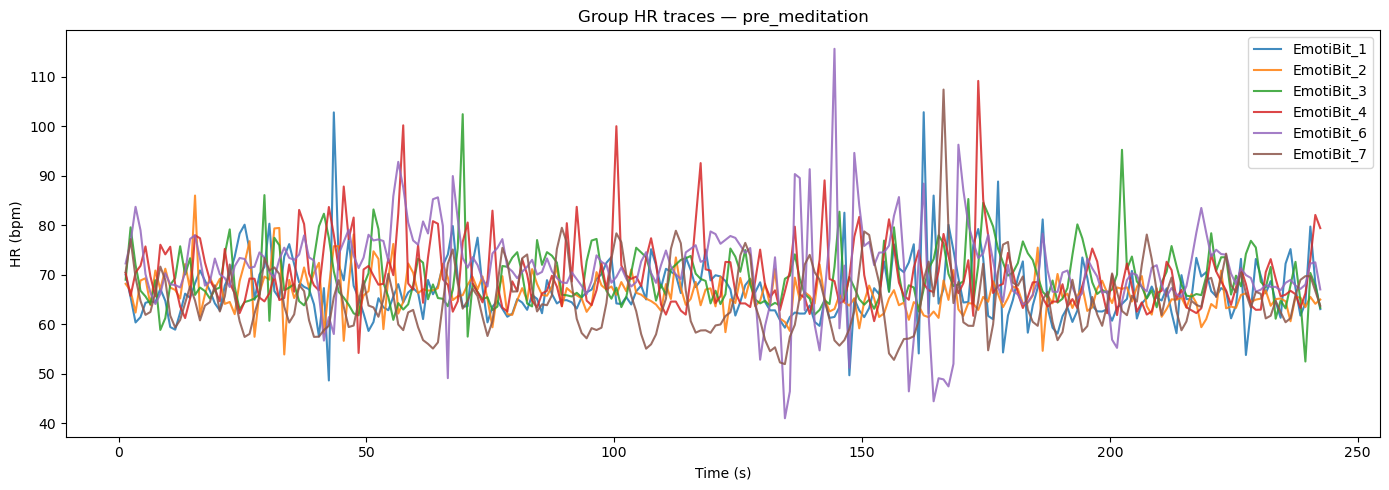

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/group_hr_traces_pre_meditation.png


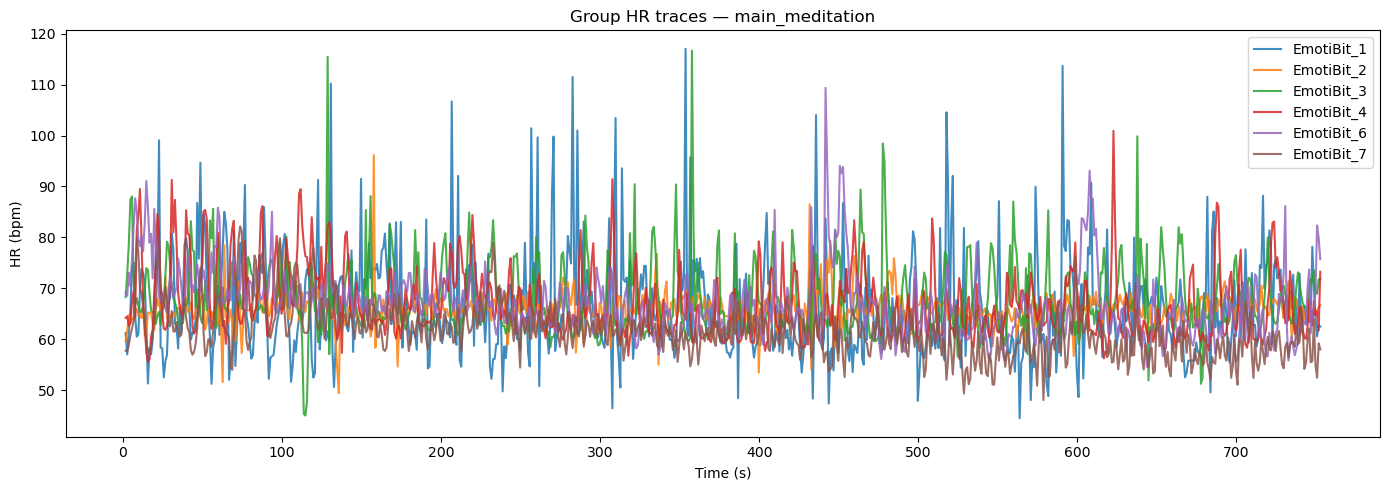

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/group_hr_traces_main_meditation.png


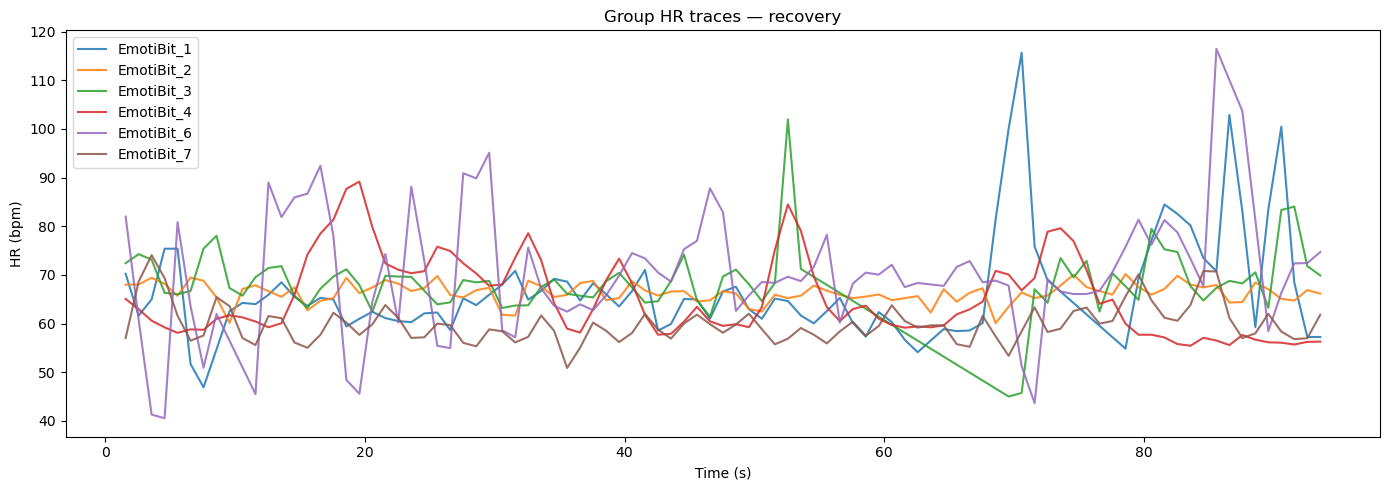

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/group_hr_traces_recovery.png


In [10]:
for segment in SEGMENTS:
    path = PROCESSED_DIR / f"group_hr_{segment}_aligned_1s.csv"
    if not path.exists():
        continue

    df = pd.read_csv(path)

    plt.figure(figsize=(14, 5))
    for emotibit_id in VALID_EMOTIBIT_IDS:
        if emotibit_id in df.columns:
            plt.plot(df["time_sec"], df[emotibit_id], label=emotibit_id, alpha=0.85)

    plt.title(f"Group HR traces — {segment}")
    plt.xlabel("Time (s)")
    plt.ylabel("HR (bpm)")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"group_hr_traces_{segment}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

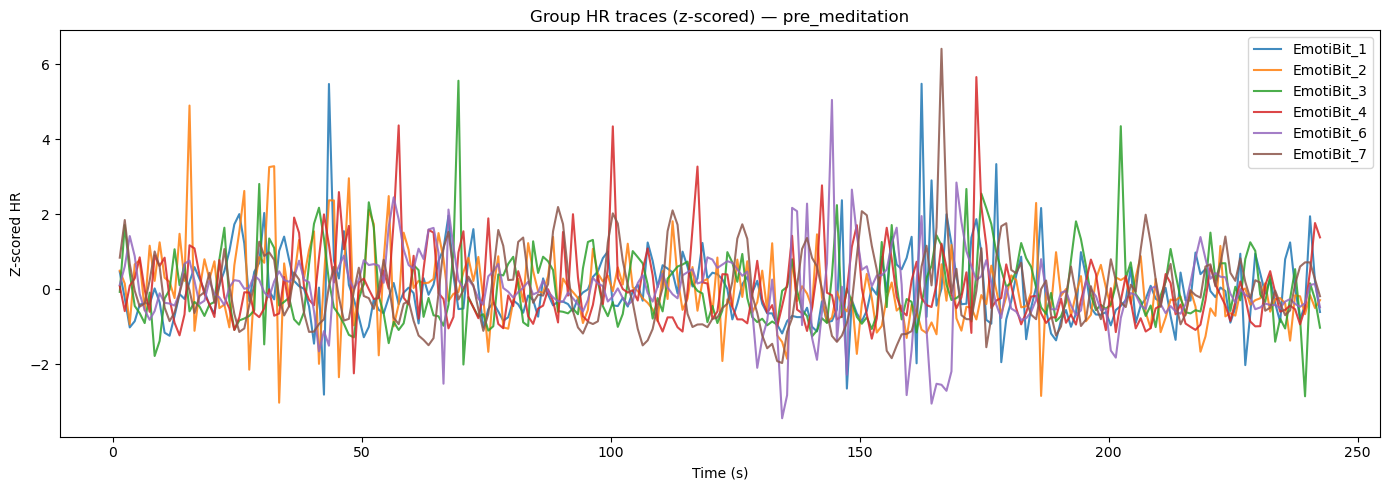

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/group_hr_traces_zscored_pre_meditation.png


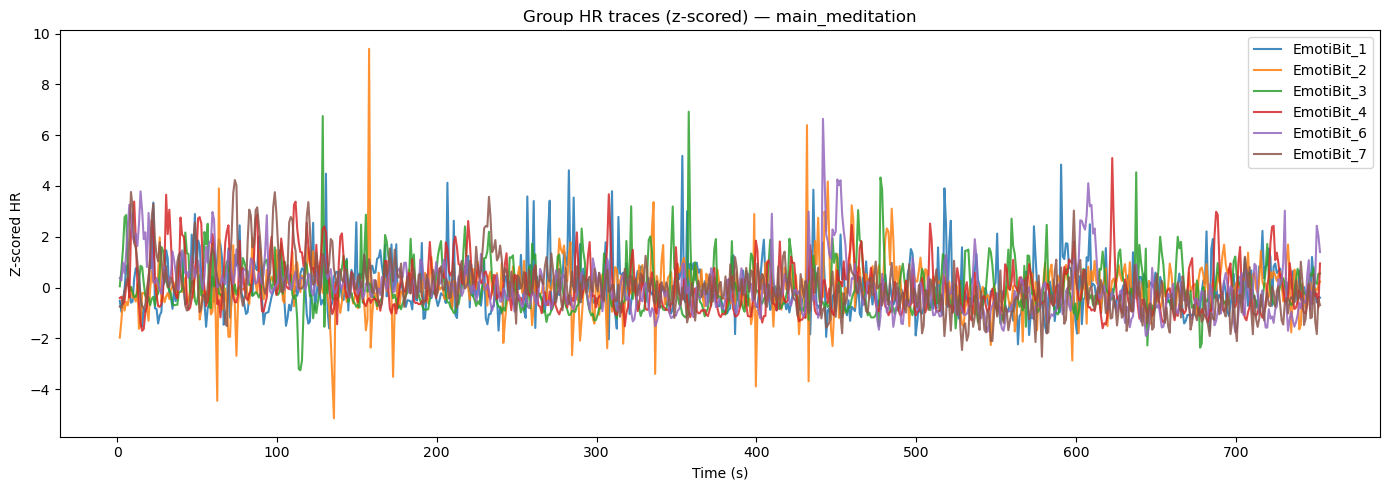

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/group_hr_traces_zscored_main_meditation.png


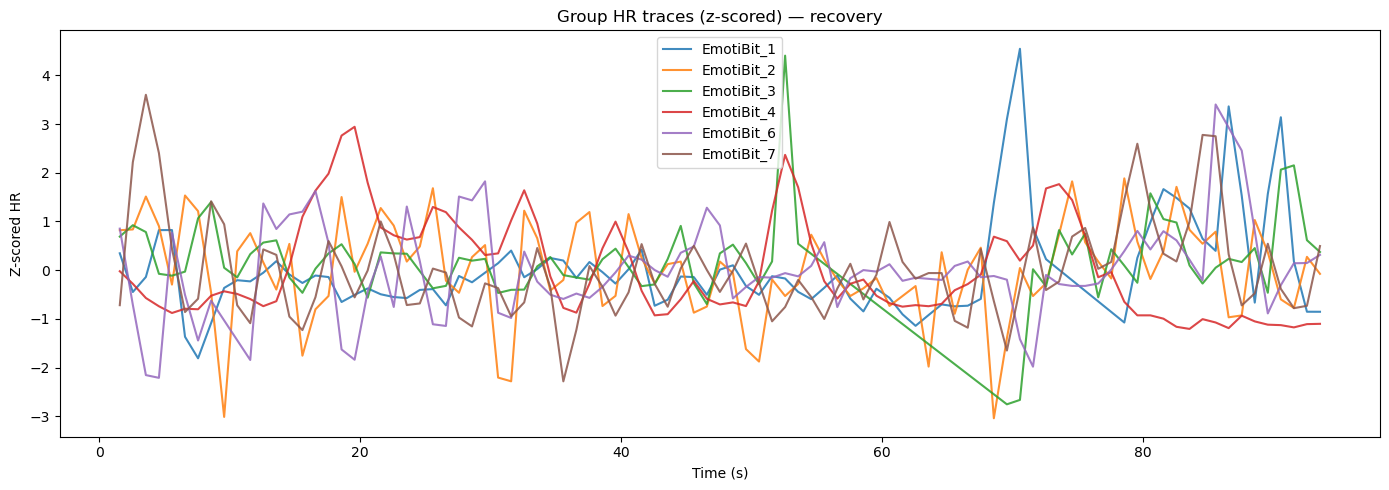

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/group_hr_traces_zscored_recovery.png


In [11]:
def zscore_series(s):
    s = pd.Series(s)
    mu = s.mean(skipna=True)
    sd = s.std(skipna=True)
    if pd.isna(sd) or sd == 0:
        return s - mu
    return (s - mu) / sd


for segment in SEGMENTS:
    path = PROCESSED_DIR / f"group_hr_{segment}_aligned_1s.csv"
    if not path.exists():
        continue

    df = pd.read_csv(path)
    plot_df = pd.DataFrame({"time_sec": df["time_sec"]})

    for emotibit_id in VALID_EMOTIBIT_IDS:
        if emotibit_id in df.columns:
            plot_df[emotibit_id] = zscore_series(df[emotibit_id])

    plt.figure(figsize=(14, 5))
    for emotibit_id in VALID_EMOTIBIT_IDS:
        if emotibit_id in plot_df.columns:
            plt.plot(plot_df["time_sec"], plot_df[emotibit_id], label=emotibit_id, alpha=0.85)

    plt.title(f"Group HR traces (z-scored) — {segment}")
    plt.xlabel("Time (s)")
    plt.ylabel("Z-scored HR")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"group_hr_traces_zscored_{segment}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

,EmotiBit_1,EmotiBit_2,EmotiBit_3,EmotiBit_4,EmotiBit_6,EmotiBit_7
EmotiBit_1,1.000000,0.022431,-0.051222,0.027891,0.057152,0.025928
EmotiBit_2,0.022431,1.000000,0.013961,0.000515,0.027457,0.075200
EmotiBit_3,-0.051222,0.013961,1.000000,-0.024278,-0.055067,0.016992
EmotiBit_4,0.027891,0.000515,-0.024278,1.000000,0.106001,-0.073249
EmotiBit_6,0.057152,0.027457,-0.055067,0.106001,1.000000,-0.101125
EmotiBit_7,0.025928,0.075200,0.016992,-0.073249,-0.101125,1.000000


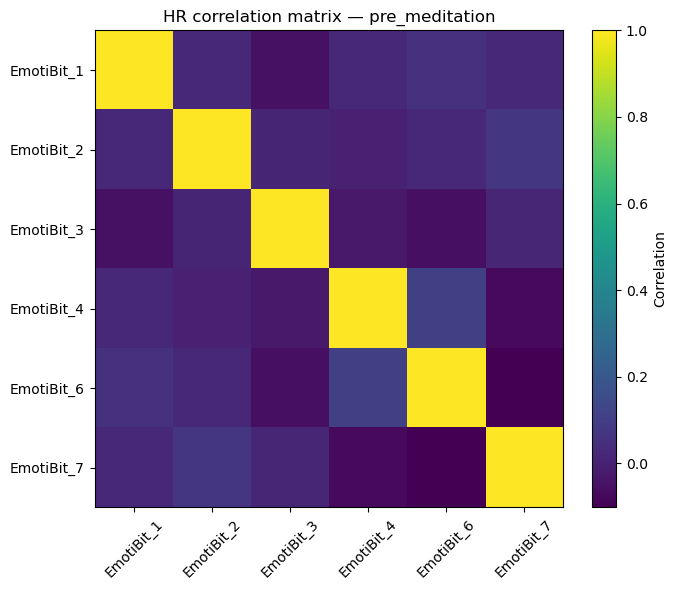

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/group_hr_corr_matrix_pre_meditation.png


,EmotiBit_1,EmotiBit_2,EmotiBit_3,EmotiBit_4,EmotiBit_6,EmotiBit_7
EmotiBit_1,1.000000,-0.010215,-0.094110,0.038548,0.037984,0.034698
EmotiBit_2,-0.010215,1.000000,-0.027347,0.041600,-0.040121,0.028570
EmotiBit_3,-0.094110,-0.027347,1.000000,0.048703,0.036377,0.012432
EmotiBit_4,0.038548,0.041600,0.048703,1.000000,0.163554,0.235680
EmotiBit_6,0.037984,-0.040121,0.036377,0.163554,1.000000,0.183601
EmotiBit_7,0.034698,0.028570,0.012432,0.235680,0.183601,1.000000


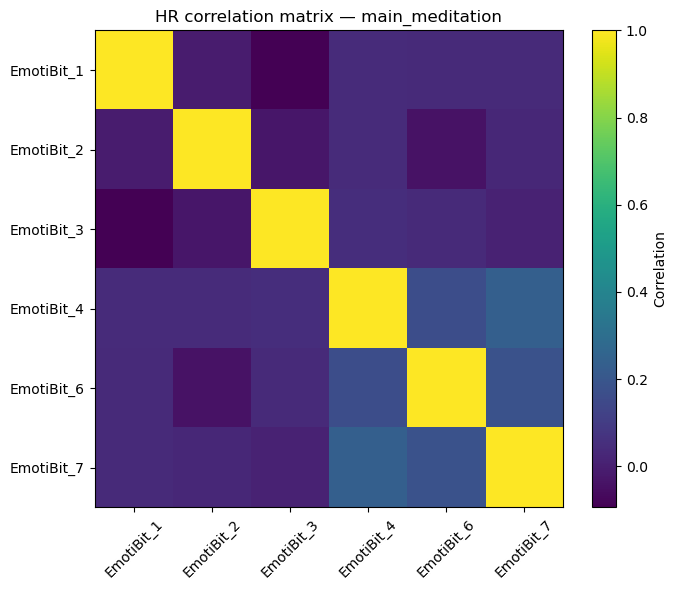

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/group_hr_corr_matrix_main_meditation.png


,EmotiBit_1,EmotiBit_2,EmotiBit_3,EmotiBit_4,EmotiBit_6,EmotiBit_7
EmotiBit_1,1.000000,-0.156835,-0.092959,-0.130879,0.124295,0.031891
EmotiBit_2,-0.156835,1.000000,0.230094,0.000744,-0.078504,0.243274
EmotiBit_3,-0.092959,0.230094,1.000000,0.047645,0.067260,0.131842
EmotiBit_4,-0.130879,0.000744,0.047645,1.000000,-0.173628,-0.236656
EmotiBit_6,0.124295,-0.078504,0.067260,-0.173628,1.000000,-0.067369
EmotiBit_7,0.031891,0.243274,0.131842,-0.236656,-0.067369,1.000000


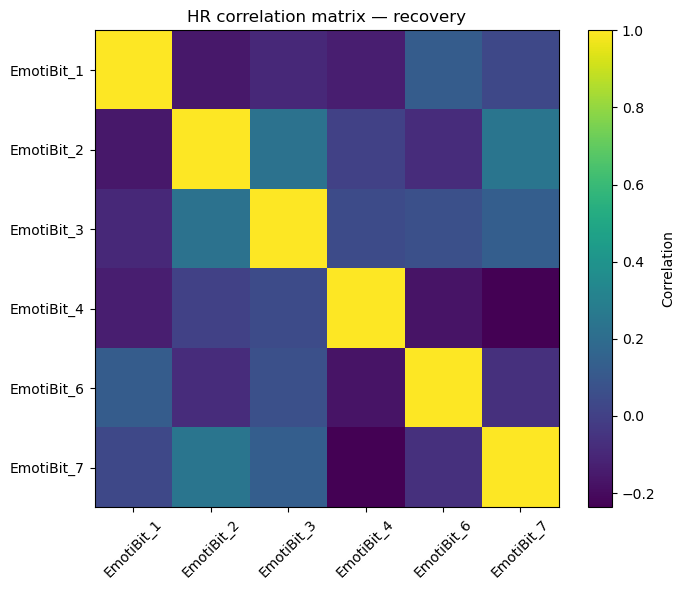

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/group_hr_corr_matrix_recovery.png


In [12]:
for segment in SEGMENTS:
    path = PROCESSED_DIR / f"group_hr_{segment}_aligned_1s.csv"
    if not path.exists():
        continue

    df = pd.read_csv(path)
    corr = df[VALID_EMOTIBIT_IDS].corr()

    display(corr)

    plt.figure(figsize=(7, 6))
    plt.imshow(corr, aspect="auto")
    plt.xticks(range(len(VALID_EMOTIBIT_IDS)), VALID_EMOTIBIT_IDS, rotation=45)
    plt.yticks(range(len(VALID_EMOTIBIT_IDS)), VALID_EMOTIBIT_IDS)
    plt.colorbar(label="Correlation")
    plt.title(f"HR correlation matrix — {segment}")
    plt.tight_layout()

    out_path = FIGURES_DIR / f"group_hr_corr_matrix_{segment}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [13]:
print("=== BUILD GROUP HR TIMESERIES SUMMARY ===")
print("Created regular 1-second aligned HR time series for the 6 included subjects.")
print("Outputs are ready for group synchrony analysis.")
print()
print("Next notebook:")
print("08_group_synchrony_basic.ipynb")

=== BUILD GROUP HR TIMESERIES SUMMARY ===
Created regular 1-second aligned HR time series for the 6 included subjects.
Outputs are ready for group synchrony analysis.

Next notebook:
08_group_synchrony_basic.ipynb
